# Applied AI & ML Capstone Project

## Part 1 – Data Acquisition, Cleaning, and Exploratory Data Analysis

**Student:** Pallavi Gupta

**Dataset:** Ames Housing Dataset

### Objective

The objective of this notebook is to perform data acquisition, preprocessing, cleaning, and exploratory data analysis (EDA) on the Ames Housing dataset. The workflow includes missing value analysis, duplicate detection, data type optimization, descriptive statistics, skewness analysis, outlier detection, visualization, correlation analysis, grouped aggregation, and saving the cleaned dataset for subsequent machine learning tasks.

# Part 1 – Data Acquisition, Cleaning, and Exploratory Data Analysis

**Applied AI & ML Capstone Project**  
Masai School × IIT Patna

**Dataset:** Ames Housing Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Optional: Improve plot appearance
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("data/AmesHousing.csv")

In [4]:
# First five rows
print("First Five Rows:")
display(df.head())

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Information:")
df.info()

# Shape
print("\nDataset Shape:")
print(df.shape)

First Five Rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900



Data Types:
Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  

## Initial Data Inspection

In this section, the dataset is loaded and inspected by displaying the first five rows, data types, dataset information, and overall shape.

## Missing Value Analysis

This section identifies missing values in each column, calculates the percentage of missing data, and determines which columns have more than 20% missing values.

In [5]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_count / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Sort by highest percentage of missing values
missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

print("Missing Value Summary:")
display(missing_summary)

Missing Value Summary:


,Missing Count,Missing Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
...,...,...
Mo Sold,0,0.000000
Yr Sold,0,0.000000
Sale Type,0,0.000000
Sale Condition,0,0.000000


In [6]:
# Columns with more than 20% missing values
high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 20
]

print("Columns with more than 20% missing values:")
display(high_missing)

Columns with more than 20% missing values:


,Missing Count,Missing Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423


## Handling Missing Values

Numeric columns with less than 20% missing values are imputed using the median. Columns with more than 20% missing values are left unchanged for now and will be documented separately.

In [10]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=["number"]).columns

# Store names of columns that are imputed
imputed_columns = []

for col in numeric_columns:
    missing_percent = (df[col].isnull().sum() / len(df)) * 100

    # Impute only numeric columns with less than 20% missing values
    if 0 < missing_percent < 20:
        df[col] = df[col].fillna(df[col].median())
        imputed_columns.append(col)

print("Numeric columns imputed using the median:")
print(imputed_columns)

Numeric columns imputed using the median:
['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']


In [12]:
# Check remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Columns that still contain missing values:")
display(remaining_missing.sort_values(ascending=False))

Columns that still contain missing values:


Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Garage Qual        159
Garage Finish      159
Garage Cond        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
BsmtFin Type 1      80
Bsmt Cond           80
Electrical           1
dtype: int64

## Duplicate Detection and Removal

This section identifies duplicate records in the dataset, removes them if present, and evaluates the impact on the dataset.

In [13]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows before removal: {duplicate_count}")

# Remove duplicates
df = df.drop_duplicates()

# Count rows after removal
print(f"Dataset shape after removing duplicates: {df.shape}")

# Verify duplicates
print(f"Duplicate rows remaining: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Dataset shape after removing duplicates: (2930, 82)
Duplicate rows remaining: 0


## Data Type Correction

This section examines the data types of all columns, identifies columns suitable for conversion, and compares memory usage before and after optimization.

In [14]:
print(df.dtypes)

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object


In [15]:
object_columns = df.select_dtypes(include=["object"]).columns

print("Object Columns:")
print(object_columns)

Object Columns:
Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='str')


C:\Users\palla\AppData\Local\Temp\ipykernel_32928\1444521567.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include=["object"]).columns


In [16]:
numeric_columns = df.select_dtypes(include=["number"]).columns

print("Numeric Columns:")
print(numeric_columns)

Numeric Columns:
Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')


## Data Type Correction and Memory Optimization

Columns representing categories are converted to the `category` data type to improve semantic correctness and reduce memory usage.

In [18]:
# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()

# Convert numeric-coded categorical column
df["MS SubClass"] = df["MS SubClass"].astype("category")

# Convert repetitive string column
df["Neighborhood"] = df["Neighborhood"].astype("category")

# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()

print(f"Memory before conversion: {memory_before:,} bytes")
print(f"Memory after conversion : {memory_after:,} bytes")
print(f"Memory saved            : {memory_before - memory_after:,} bytes")

Memory before conversion: 7,251,298 bytes
Memory after conversion : 7,072,791 bytes
Memory saved            : 178,507 bytes


## Descriptive Statistics and Skewness Analysis

This section summarizes the numerical features of the dataset and identifies the most skewed variables using the skewness statistic.

In [19]:
# Summary statistics for numeric columns
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,Order,PID,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,69.019795,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.096928,442.604778,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,21.326422,7880.017759,1.411026,1.111537,30.245361,20.860286,178.634545,455.515036,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,60.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,162.750000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [20]:
# Calculate skewness for all numeric columns
skewness = df.select_dtypes(include=["number"]).skew()

# Convert to a DataFrame
skewness_df = pd.DataFrame({
    "Skewness": skewness,
    "Absolute Skewness": skewness.abs()
})

# Sort by highest absolute skewness
skewness_df = skewness_df.sort_values(
    by="Absolute Skewness",
    ascending=False
)

print("Skewness of Numeric Columns:")
display(skewness_df)

Skewness of Numeric Columns:


,Skewness,Absolute Skewness
Misc Val,21.999788,21.999788
Pool Area,16.939142,16.939142
Lot Area,12.820898,12.820898
Low Qual Fin SF,12.118162,12.118162
3Ssn Porch,11.403795,11.403795
Kitchen AbvGr,4.313825,4.313825
BsmtFin SF 2,4.140794,4.140794
Enclosed Porch,4.014446,4.014446
Screen Porch,3.957467,3.957467
Bsmt Half Bath,3.942389,3.942389


In [21]:
most_skewed = skewness_df.index[0]

print(f"Most skewed numeric column: {most_skewed}")
print(f"Skewness value: {skewness_df.iloc[0]['Skewness']:.3f}")

Most skewed numeric column: Misc Val
Skewness value: 22.000


## Outlier Detection using the IQR Method

This section identifies potential outliers in selected numeric columns using the Interquartile Range (IQR) method. Outliers are documented but not removed.

In [24]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Number of Outliers: {len(outliers)}")

In [23]:
detect_outliers_iqr(df, "SalePrice")
detect_outliers_iqr(df, "Gr Liv Area")


Column: SalePrice
Q1: 129500.0
Q3: 213500.0
IQR: 84000.0
Lower Bound: 3500.0
Upper Bound: 339500.0
Number of Outliers: 137

Column: Gr Liv Area
Q1: 1126.0
Q3: 1742.75
IQR: 616.75
Lower Bound: 200.875
Upper Bound: 2667.875
Number of Outliers: 75


In [25]:
detect_outliers_iqr(df, "SalePrice")
detect_outliers_iqr(df, "Gr Liv Area")


Column: SalePrice
Q1: 129500.0
Q3: 213500.0
IQR: 84000.0
Lower Bound: 3500.0
Upper Bound: 339500.0
Number of Outliers: 137

Column: Gr Liv Area
Q1: 1126.0
Q3: 1742.75
IQR: 616.75
Lower Bound: 200.875
Upper Bound: 2667.875
Number of Outliers: 75


## Visualization 1: Line Plot

This plot shows how the house sale prices vary across the dataset based on the row index.

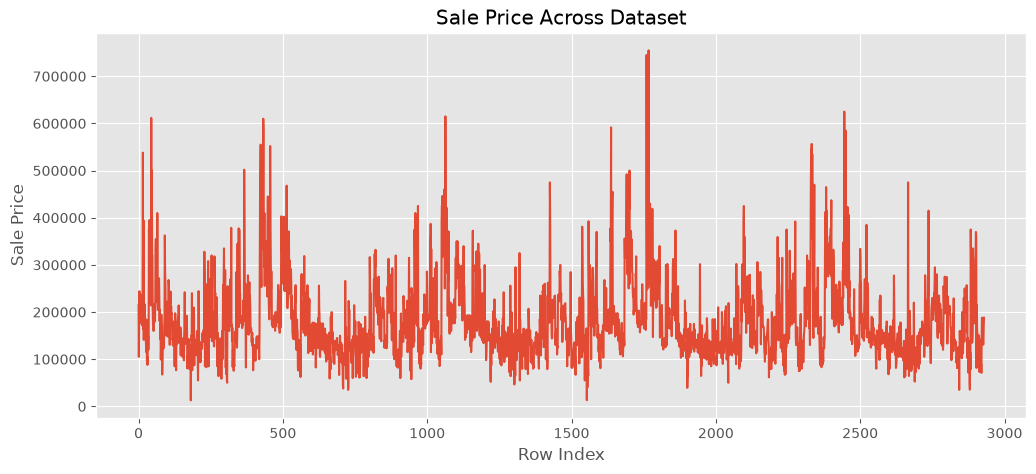

In [26]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["SalePrice"])

plt.title("Sale Price Across Dataset")
plt.xlabel("Row Index")
plt.ylabel("Sale Price")

plt.show()

## Visualization 2: Bar Chart

This chart compares the average sale price across different zoning categories.

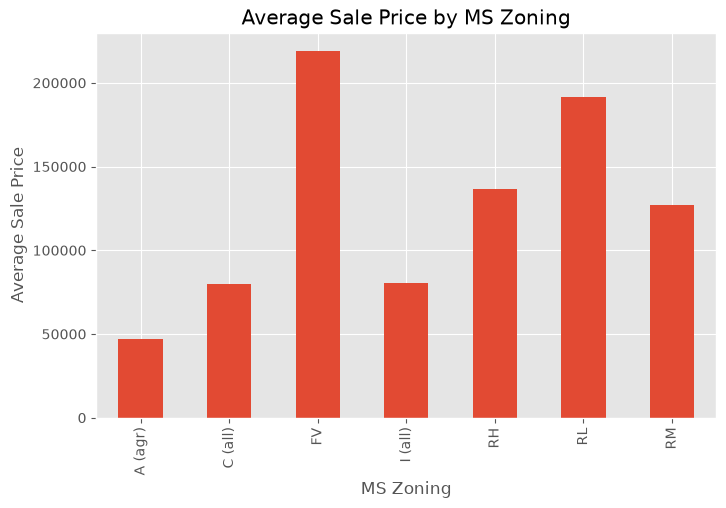

In [27]:
plt.figure(figsize=(8,5))

df.groupby("MS Zoning")["SalePrice"].mean().plot(kind="bar")

plt.title("Average Sale Price by MS Zoning")
plt.xlabel("MS Zoning")
plt.ylabel("Average Sale Price")

plt.show()

## Visualization 3: Histogram

This histogram shows the distribution of the most skewed numeric column (Misc Val).

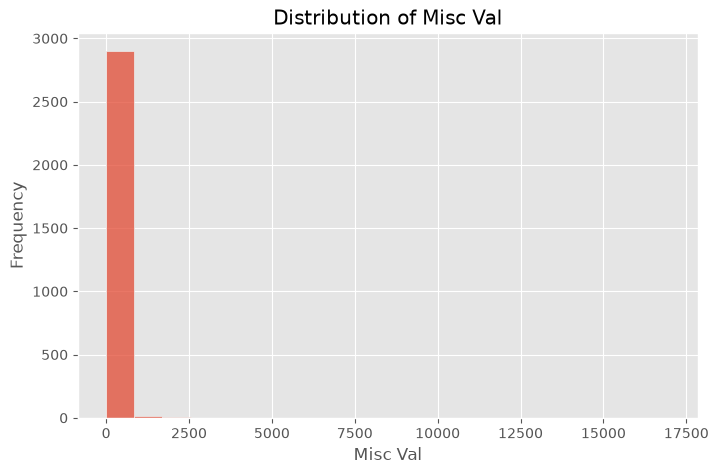

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["Misc Val"], bins=20)

plt.title("Distribution of Misc Val")
plt.xlabel("Misc Val")
plt.ylabel("Frequency")

plt.show()

## Visualization 4: Scatter Plot

A scatter plot is used to examine the relationship between two numerical variables. Here, the relationship between **Ground Living Area (Gr Liv Area)** and **Sale Price (SalePrice)** is visualized to determine whether larger houses tend to sell for higher prices.

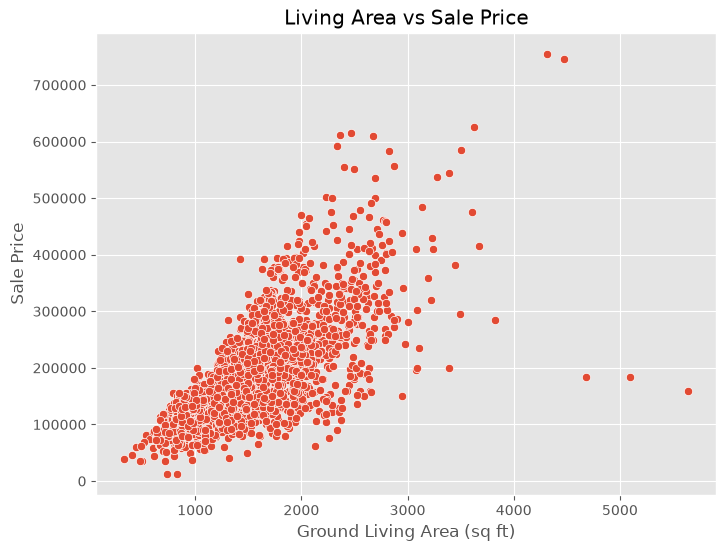

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

## Visualization 5: Box Plot

A box plot is used to compare the distribution of sale prices across different zoning categories. It highlights the median, spread, and potential outliers within each category.

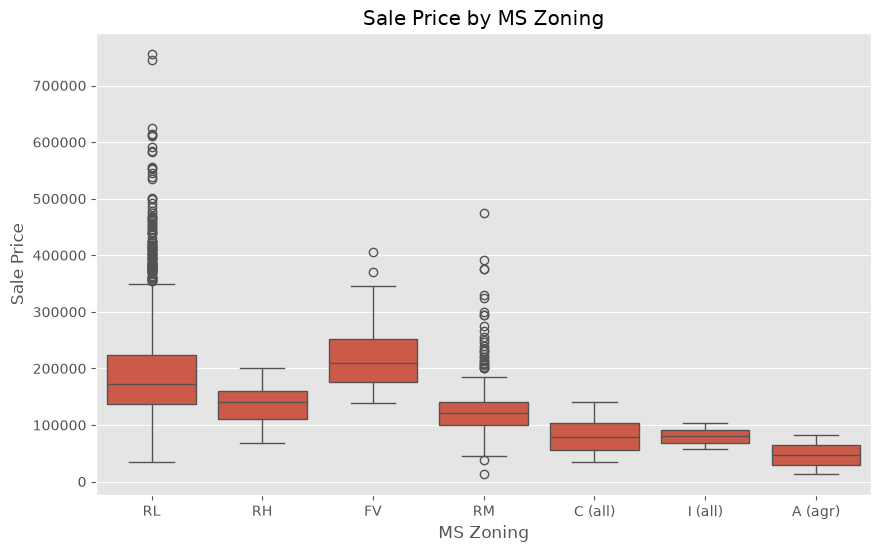

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="MS Zoning",
    y="SalePrice"
)

plt.title("Sale Price by MS Zoning")
plt.xlabel("MS Zoning")
plt.ylabel("Sale Price")

plt.show()

## Visualization 6: Correlation Heatmap

The Pearson correlation matrix is computed for all numerical variables and visualized using a heatmap. This helps identify strongly correlated features that may be useful for predictive modeling.

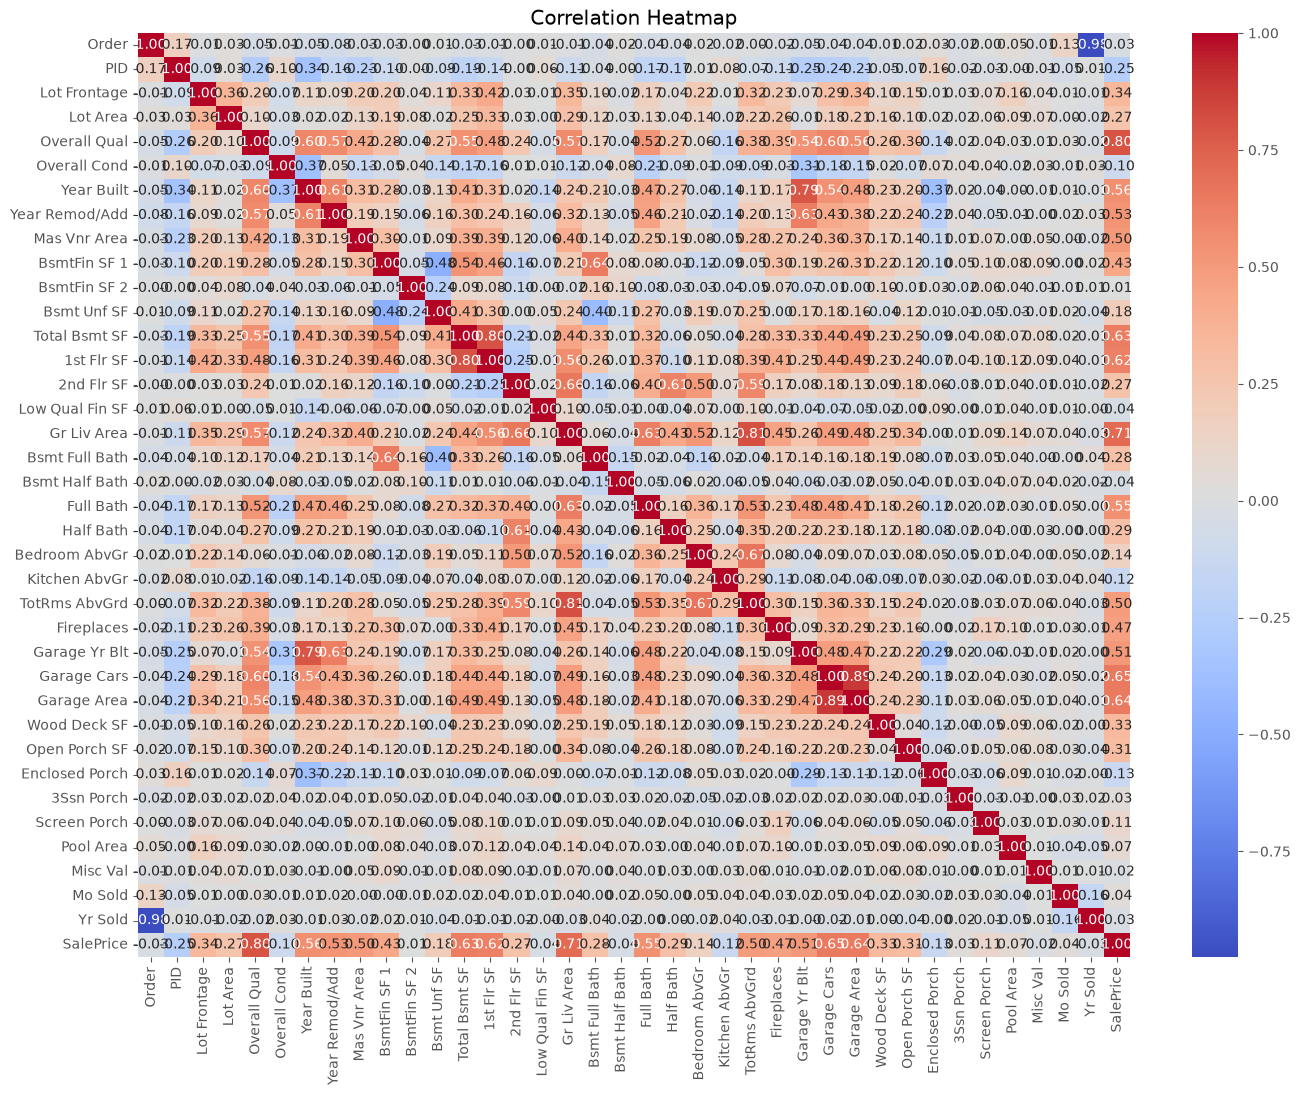

In [31]:
numeric_df = df.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Imputation Strategy Comparison

The two most skewed numerical columns are examined by comparing their mean and median values. Since skewed distributions are influenced by extreme values, the median is generally a more representative measure of central tendency for imputing missing values.

In [32]:
top2 = skewness_df.head(2).index

for col in top2:
    print(f"\nColumn: {col}")
    print("Mean :", df[col].mean())
    print("Median:", df[col].median())


Column: Misc Val
Mean : 50.63515358361775
Median: 0.0

Column: Pool Area
Mean : 2.243344709897611
Median: 0.0


In [33]:
for col in top2:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(df[top2].isnull().sum())

Misc Val     0
Pool Area    0
dtype: int64


## Spearman Rank Correlation Analysis

In addition to Pearson correlation, Spearman rank correlation is calculated to identify monotonic relationships between numerical variables. Differences between the two correlation measures help detect relationships that may not be strictly linear.

In [34]:
pearson = numeric_df.corr()

spearman = numeric_df.corr(method="spearman")

print("Pearson Correlation")
display(pearson)

print("Spearman Correlation")
display(spearman)

Pearson Correlation


,Order,PID,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.173593,-0.006102,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.031045,-0.032313,...,-0.011292,0.016355,0.027908,-0.024975,0.004307,0.052518,-0.006083,0.133365,-0.975993,-0.031408
PID,0.173593,1.000000,-0.087894,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.225672,-0.098412,...,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
Lot Frontage,-0.006102,-0.087894,1.000000,0.362758,0.198917,-0.067140,0.114341,0.086139,0.201685,0.198161,...,0.102790,0.150107,0.012165,0.025157,0.070101,0.160860,0.035368,0.010477,-0.007123,0.340256
Lot Area,0.031354,0.034868,0.362758,1.000000,0.097188,-0.034759,0.023258,0.021682,0.125950,0.191574,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,-0.048500,-0.263147,0.198917,0.097188,1.000000,-0.094812,0.597027,0.569609,0.423089,0.284091,...,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,-0.011054,0.104451,-0.067140,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.132472,-0.050991,...,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,-0.052319,-0.343388,0.114341,0.023258,0.597027,-0.368773,1.000000,0.612095,0.306797,0.279881,...,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,-0.075566,-0.157111,0.086139,0.021682,0.569609,0.047680,0.612095,1.000000,0.191740,0.151809,...,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,-0.031045,-0.225672,0.201685,0.125950,0.423089,-0.132472,0.306797,0.191740,1.000000,0.299841,...,0.165875,0.140003,-0.109915,0.014222,0.066817,0.004893,0.045276,-0.002358,-0.016876,0.502196
BsmtFin SF 1,-0.032313,-0.098412,0.198161,0.191574,0.284091,-0.050991,0.279881,0.151809,0.299841,1.000000,...,0.224028,0.124974,-0.100433,0.050546,0.095888,0.084143,0.092890,-0.001110,0.022389,0.432862


Spearman Correlation


,Order,PID,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.205863,-0.018968,0.012684,-0.049175,-0.015534,-0.056978,-0.084144,-0.041874,-0.034219,...,-0.025811,0.000760,0.025225,-0.015117,0.006032,0.047986,-0.038106,0.142150,-0.977264,-0.035703
PID,0.205863,1.000000,-0.085170,-0.040342,-0.314353,0.111922,-0.314979,-0.208414,-0.233338,-0.050328,...,-0.092368,-0.176972,0.152769,0.005809,0.006353,0.003222,0.018754,-0.051290,0.003198,-0.270660
Lot Frontage,-0.018968,-0.085170,1.000000,0.573014,0.207339,-0.098224,0.185710,0.120682,0.255081,0.156450,...,0.109976,0.159865,-0.097697,0.009730,0.079372,0.078772,0.034338,0.007870,0.000969,0.370670
Lot Area,0.012684,-0.040342,0.573014,1.000000,0.196855,-0.079006,0.121151,0.103266,0.203267,0.171297,...,0.177609,0.171777,-0.042467,0.029028,0.091527,0.083071,0.073861,0.004774,-0.021720,0.429249
Overall Qual,-0.049175,-0.314353,0.207339,0.196855,1.000000,-0.189638,0.664590,0.579323,0.414913,0.179159,...,0.290231,0.440433,-0.192093,0.019398,0.026212,0.033057,-0.076443,0.029163,-0.017015,0.808800
Overall Cond,-0.015534,0.111922,-0.098224,-0.079006,-0.189638,1.000000,-0.422306,-0.075119,-0.177249,-0.020646,...,-0.036363,-0.175446,0.134745,0.044303,0.050333,-0.020386,0.061434,-0.006480,0.039612,-0.165657
Year Built,-0.056978,-0.314979,0.185710,0.121151,0.664590,-0.422306,1.000000,0.707678,0.388014,0.214540,...,0.296569,0.402890,-0.434250,0.011180,-0.066507,0.004203,-0.079103,0.016111,-0.009527,0.680822
Year Remod/Add,-0.084144,-0.208414,0.120682,0.103266,0.579323,-0.075119,0.707678,1.000000,0.240754,0.087744,...,0.249966,0.372293,-0.268871,0.049288,-0.058677,-0.011139,-0.057701,0.014296,0.041084,0.601454
Mas Vnr Area,-0.041874,-0.233338,0.255081,0.203267,0.414913,-0.177249,0.388014,0.240754,1.000000,0.268895,...,0.185712,0.213622,-0.186199,0.025765,0.059830,0.001738,-0.039001,0.009129,-0.007162,0.434773
BsmtFin SF 1,-0.034219,-0.050328,0.156450,0.171297,0.179159,-0.020646,0.214540,0.087744,0.268895,1.000000,...,0.208274,0.094946,-0.146952,0.060471,0.092409,0.030037,0.019956,-0.006601,0.025814,0.331962


difference table:

In [35]:
difference = (spearman - pearson).abs()

difference = difference.unstack()

difference = difference.reset_index()

difference.columns = [
    "Column 1",
    "Column 2",
    "Difference"
]

difference = difference[
    difference["Column 1"] < difference["Column 2"]
]

difference = difference.sort_values(
    by="Difference",
    ascending=False
)

display(difference.head(3))

,Column 1,Column 2,Difference
116,Lot Area,Lot Frontage,0.210256
1108,Open Porch SF,Year Built,0.204525
979,Garage Yr Blt,Open Porch SF,0.173485


## Grouped Aggregation Analysis

The dataset is grouped by **MS Zoning**, and summary statistics (mean, standard deviation, and count) of **SalePrice** are computed. This analysis helps evaluate whether zoning categories provide useful predictive information.

In [36]:
group_stats = df.groupby("MS Zoning")["SalePrice"].agg(
    ["mean","std","count"]
)

display(group_stats)

,mean,std,count
MS Zoning,,,
A (agr),47300.000000,48366.103833,2
C (all),79795.040000,31084.817206,25
FV,218986.949640,52684.229037,139
I (all),80312.500000,32084.970196,2
RH,136419.777778,36173.101244,27
RL,191283.251650,81295.736203,2273
RM,126781.393939,48145.542821,462


In [37]:
highest_mean = group_stats["mean"].idxmax()

highest_std = group_stats["std"].idxmax()

ratio = group_stats["mean"].max() / group_stats["mean"].min()

print("Highest Mean Group:", highest_mean)

print("Highest Std Group:", highest_std)

print("Mean Ratio:", ratio)

Highest Mean Group: FV
Highest Std Group: RL
Mean Ratio: 4.629745235524054


In [38]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv saved successfully!")

cleaned_data.csv saved successfully!


## Saving the Cleaned Dataset

The cleaned and preprocessed dataset is saved as **cleaned_data.csv**. This file will be used as the input dataset for Parts 2 and 3 of the capstone project.